# Proyecto: Análisis estadístico sobre hábitos saludables en jóvenes universitarios
## Clase 1: Método científico y estadística

1. Definición del problema a investigar

El equipo de investigación del área de salud universitaria ha detectado una preocupación creciente sobre el bienestar de los estudiantes. El problema se define como: ¿Existe una relación significativa entre la cantidad de horas de sueño diarias y el rendimiento académico (medido por el promedio de notas) en los jóvenes universitarios de la institución?

2. Formulación de hipótesis

* Hipótesis Nula (H0​): No existe relación entre las horas de sueño y el rendimiento académico.
* Hipótesis Alternativa (H1​): Los estudiantes que duermen al menos 7 horas diarias presentan un rendimiento académico significativamente mayor que aquellos que duermen menos de 7 horas.

3. Indentificación de variables relevantes

*  Variables cuantitativas: 
    * Horas de sueño: Variable continua (promedio de horas por noche).
    * Rendimiento académico: Variable continua (promedio general de calificaciones de 1.0 a 7.0).

* Variables cualitativas:
    * Nivel de actividad física: Ordinal (Bajo, Medio, Alto).
    * Calidad percibidad del sueño: Ordinal (Mala, Regular, Buena, Excelente).
    * Facultad de pertenencia: Nominal.

4. Enfoque del método científico elegido

Se aplicará un enfoque cuantitativo. Este método es el más adecuado ya que:

* Utiliza datos numéricos y análisis estadísticos para confirmar o rechazar la hipótesis.
* Busca establecer patrones y realizar generalizaciones a partir de una muestra representativa de la población universitaria.
* Garantiza la reproducibilidad y objetividad, permitiendo que otros investigadores validen los hallazgos basándose únicamente en la evidencia de los datos. 

5. Diseño preliminar del estudio

El estudio seguirá un diseño experimental o cuasi-experimental dependiendo de la capacidad de control:
* Población: Todos los estudiantes de la institución pública.
* Muestra: Se seleccionará una muestra aleatoria de al menos 100 registros para asegurar la representatividad y minimizar sesgos de selección.
* Recolección de datos: Se utilizará un instrumento de medición diseñado para capturar las variables menciones, asegurando la fiabilidad de la medición.
* Análisis previsto: Se realizará una comparación de medias y se calculará el valor p para determinar si los resultados son estadísticamente significativos (α=0.05).

## Clase 2: Probabilidad y estadística

1. Definición de eventos aleatorios

Para nuestro estudio sobre el sueño y el rendimiento definimos los siguientes eventos:
* Evento A (S): El estudiante duerme 7 horas o más (hábitos saludables).
* Evento B (R): El estudiante tiene un promedio mayor a 5.5.

2. Plan de muestreo

Dado que los hábitos de sueño y carga académica pueden variar según la carrera, dividiremos la población en estratos (por ejemplo: Ingeniería, Salud, Artes) y seleccionaremos una muestra proporcional de cada uno para que los resultados no estén sesgados por una sola facultad y sea un muestreo aleatorio estratificado.

3. Simulación del Dataset

Generación de los 100 registros iniciales:

In [28]:
import pandas as pd
import numpy as np

# Configurar semilla para que los resultados sean reproducibles
np.random.seed(42)

# Simulación de 100 estudiantes
n = 100
data = {
    'ID': range(1, n + 1),
    'Facultad': np.random.choice(['Ingeniería', 'Salud', 'Artes', 'Sociales'], n),
    'Horas_Sueno': np.random.normal(6.5, 1.5, n).round(1), # Media 6.5, DS 1.5
    'Promedio_Notas': np.random.uniform(1.0, 7.0, n).round(2),
    'Actividad_Fisica': np.random.choice(['Bajo', 'Medio', 'Alto'], n, p=[0.4, 0.4, 0.2])
}

df = pd.DataFrame(data)

# Ajustaremos un poco los datos para que tengan sentido con nuestra hipótesis
# (Sumamos un pequeño bono al promedio si duermen > 7 horas)
df.loc[df['Horas_Sueno'] >= 7, 'Promedio_Notas'] = (df['Promedio_Notas'] + 0.5).clip(1.0, 7.0)

print("Primeros 5 registros del dataset:")
print(df.head())

# GUARDAR EL ARCHIVO (Asegurando que no haya errores de formato)
df.to_csv('estudiantes.csv', index=False)

Primeros 5 registros del dataset:
   ID    Facultad  Horas_Sueno  Promedio_Notas Actividad_Fisica
0   1       Artes          7.6            6.40            Medio
1   2    Sociales          6.8            4.33            Medio
2   3  Ingeniería          6.3            4.18             Bajo
3   4       Artes          6.0            2.45            Medio
4   5       Artes          4.3            1.56             Bajo


4. Cálculo de probabilidades básicas

Utilizando el dataset simulado, calcularemos las probabilidades solicitadas:
* P(A) - Probabilidad de dormir bien (≥7 hrs):
* P(A)=TotalEstudiantes que duermen ≥7​

* P(B) - Probabilidad de tener promedio alto (>5.5):
* P(B)=TotalEstudiantes con promedio >5.5​

* P(A ∩ B) - Intersección: Probabilidad de que un estudiante duerma bien Y tenga buen promedio.

* P(A ∪ B) - Unión: Probabilidad de que duerma bien o tenga buen promedio.

In [29]:
# Definir condiciones
dormir_bien = df['Horas_Sueno'] >= 7
promedio_alto = df['Promedio_Notas'] > 5.5

# Cálculos
p_a = dormir_bien.mean()
p_b = promedio_alto.mean()
p_interseccion = (dormir_bien & promedio_alto).mean()
p_union = (dormir_bien | promedio_alto).mean()
p_complemento_a = 1 - p_a

print(f"P(Dormir Bien): {p_a:.2f}")
print(f"P(Promedio Alto): {p_b:.2f}")
print(f"P(Intersección A y B): {p_interseccion:.2f}")
print(f"P(Unión A o B): {p_union:.2f}")
print(f"P(No dormir bien - Complemento): {p_complemento_a:.2f}")

P(Dormir Bien): 0.36
P(Promedio Alto): 0.36
P(Intersección A y B): 0.17
P(Unión A o B): 0.55
P(No dormir bien - Complemento): 0.64


#### Apéndice: Diccionario de Variables (Data Dictionary)

Este diccionario describe el conjunto de datos simulado para el estudio de hábitos saludables en jóvenes universitarios. El dataset consta de 100 registros y 5 variables.

1. Conceptos claves

* **Distribución pobacional**: Es la forma que tienen todos nuestros datos (los 100 registros originales).

* **Distribución Muestral de la Media**: Es la distribución que se forma si tomamos muchas muestras pequeñas del grupo original y graficamos sus promedios.

* **Importancia del TLC**: Nos permite usar herramientas de la distribución normal (como intervalos de confianza) incluso si nuestros datos originales no son perfectamente normales, siempre que el tamaño de la muestra sea suficiente (usualmente n≥30).

* Un **intervalo de confianza** nos da un rango de valores en el que estamos razonablemente seguros de que se encuentra el verdadero parámetro poblacional (la media real).
    * *Si decimos que el IC al 95% del promedio es (5.2, 5.8), significa que si repitiéramos el muestreo muchas veces, el 95% de esos intervalos contendrían la media real de la universidad.*

## Clase 3: Distribución de probabilidad

1. Identificación de distribuciones

Analizaremos nuestras variables principales para determinar su naturaleza:
* Variable "Horas de sueño" y "Promedio de notas": Se ajustan a una distribución normal (continua). Esto porque son mediciones que pueden tomar cualquier valor en un rango y tienden a agruparse alrededor de un promedio central, siguiendo la clásica forma de campana.

* Variable "Estudiantes con promedio sobresaliente" (Éxito/Fracaso): Se aleja de una distribución binomial (discreta). Esto porque si tomamos un grupo fijo de estudiantes, cada uno tiene una probabilidad p de tener promedio alto o no (experimento de Bernoulli).

* Variable "Cantidad de consultas médicas por semestre": (para el contexto) Se ajustaría a una distribución de Poisson. Esto porque modela el número de veces que ocurre un evento en un intervalo de tiempo determinado. 

2. Justificación y cálculos. 

Vamos a trabajar con la distribución normal para el promedio de notas 
y la binomial para la proporción de estudiantes con buenos hábitos.

In [30]:
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribución Normal para el Promedio de Notas
mu = df['Promedio_Notas'].mean()
sigma = df['Promedio_Notas'].std()

print(f"Media poblacional estimada (mu): {mu:.2f}")
print(f"Desviación estándar estimada (sigma): {sigma:.2f}")

# Calcular probabilidad de que un estudiante al azar tenga promedio > 6.0
prob_excelencia = 1 - stats.norm.cdf(6.0, mu, sigma)
print(f"P(Promedio > 6.0): {prob_excelencia:.4f}")

# 2. Distribución Binomial
# Si elegimos 10 estudiantes al azar, ¿cuál es la probabilidad de que 5 duerman bien?
n_ensayos = 10
p_exito = (df['Horas_Sueno'] >= 7).mean() # Probabilidad de éxito de la Clase 2
k_exitos = 5

prob_binomial = stats.binom.pmf(k_exitos, n_ensayos, p_exito)
print(f"P(5 de 10 estudiantes duermen bien): {prob_binomial:.4f}")

Media poblacional estimada (mu): 4.47
Desviación estándar estimada (sigma): 1.77
P(Promedio > 6.0): 0.1940
P(5 de 10 estudiantes duermen bien): 0.1636


3. Visualización de las distribuciones

Es fundamental graficar para validar que nuestros datos siguen la forma esperada.

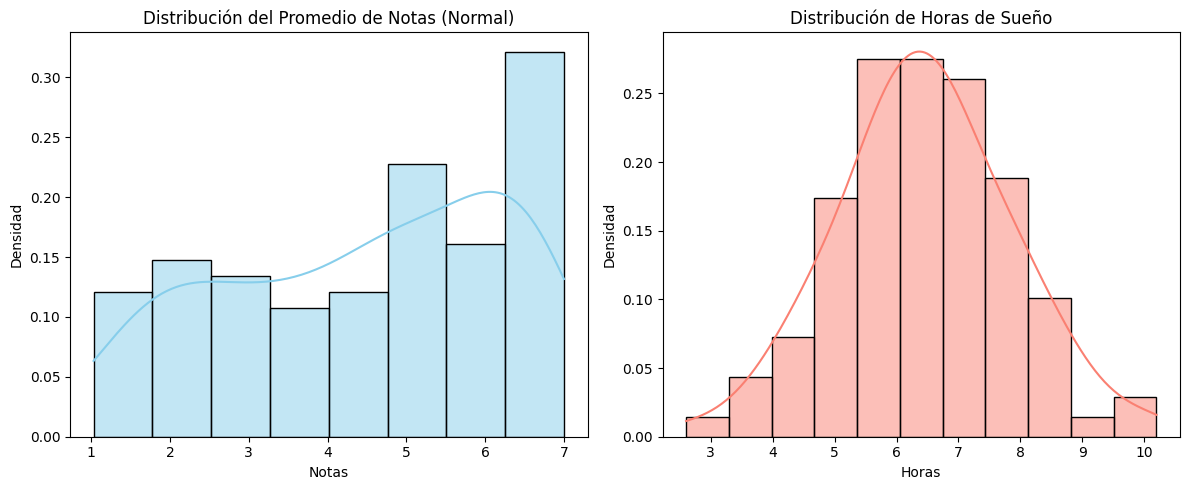

In [31]:
plt.figure(figsize=(12, 5))

# Gráfico de la Distribución Normal (Promedio de Notas)
plt.subplot(1, 2, 1)
sns.histplot(df['Promedio_Notas'], kde=True, color='skyblue', stat="density")
plt.title('Distribución del Promedio de Notas (Normal)')
plt.xlabel('Notas')
plt.ylabel('Densidad')

# Gráfico de las Horas de Sueño
plt.subplot(1, 2, 2)
sns.histplot(df['Horas_Sueno'], kde=True, color='salmon', stat="density")
plt.title('Distribución de Horas de Sueño')
plt.xlabel('Horas')
plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

4. Interpretación

Al observar los gráficos y los cálculos:
* La **Distribución Normal** nos permite predecir qué tan común es encontrar estudiantes en los extremos (muy bajo o muy alto rendimiento).
* La **Distribución Binomial** nos ayuda a entender la probabilidad de ocurrencia de un hábito en grupos pequeños, lo cual es vital para intervenciones focalizadas en facultades.

## Clase 4: Distribución muestral y Teorema del límite central (TLC)

1. Generar distribuciones muestrales de media a partir del dataset simulado.

2. Verificar empíricamente el Teorema del Límite Central

Media de la población original: 4.4709
Media de las 1000 muestras: 4.4607


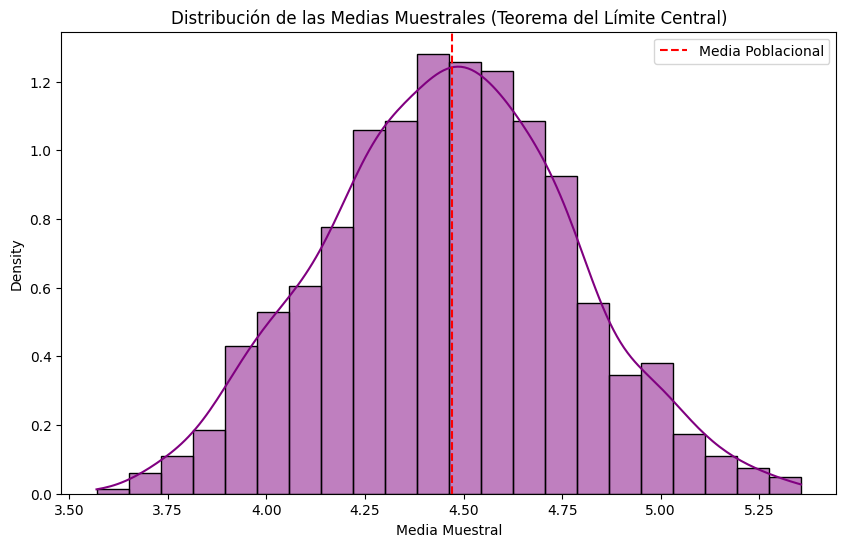

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración del experimento
num_muestras = 1000
tamano_muestra = 30
medias_muestrales = []

# Generar las 1000 medias
for _ in range(num_muestras):
    muestra = df['Promedio_Notas'].sample(n=tamano_muestra, replace=True)
    medias_muestrales.append(muestra.mean())

# Convertir a Serie de pandas para facilitar el análisis
medias_muestrales = pd.Series(medias_muestrales)

# 2. Verificar el Teorema del Límite Central 
print(f"Media de la población original: {df['Promedio_Notas'].mean():.4f}")
print(f"Media de las 1000 muestras: {medias_muestrales.mean():.4f}")

plt.figure(figsize=(10, 6))
sns.histplot(medias_muestrales, kde=True, color='purple', stat="density")
plt.title('Distribución de las Medias Muestrales (Teorema del Límite Central)')
plt.xlabel('Media Muestral')

# Agregar línea vertical para la media poblacional
plt.axvline(df['Promedio_Notas'].mean(), color='red', linestyle='--', label='Media Poblacional')
plt.legend()
plt.show()  


* *Al ver que ambos números son casi idénticos en el output, se comprueba la teoría del límite central (TLC) en la práctica.*

3. Comparación Visual: Población vs. Distribución Muestral

Para demostrar el TLC, graficaremos ambas distribuciones lado a lado. Verás que la distribución muestral es mucho más estrecha y simétrica.

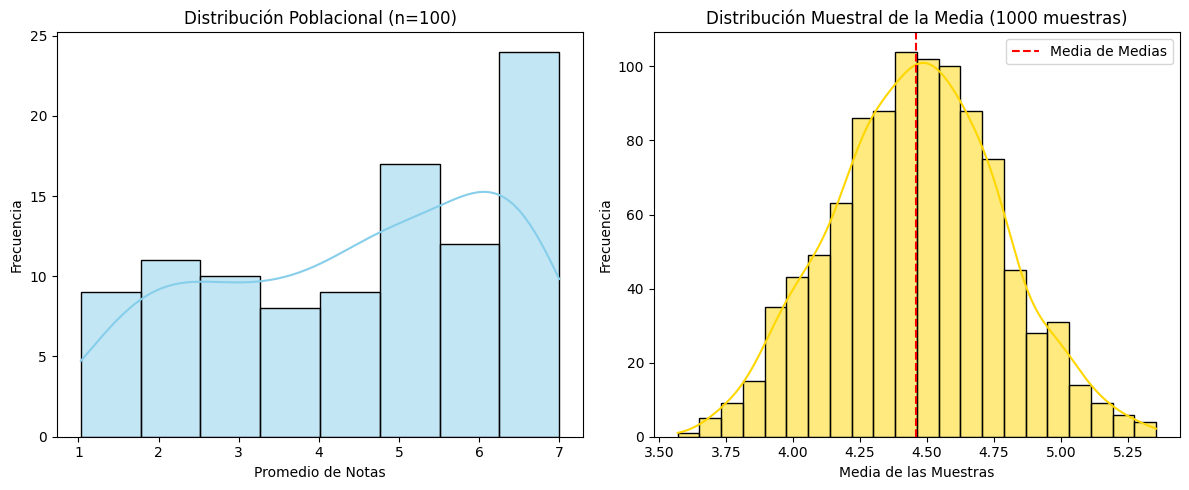

In [33]:
plt.figure(figsize=(12, 5))

# Distribución Poblacional
plt.subplot(1, 2, 1)
sns.histplot(df['Promedio_Notas'], color='skyblue', kde=True)
plt.title('Distribución Poblacional (n=100)')
plt.xlabel('Promedio de Notas')
plt.ylabel('Frecuencia')

# Distribución Muestral de la Media
plt.subplot(1, 2, 2)
sns.histplot(medias_muestrales, color='gold', kde=True)
plt.axvline(medias_muestrales.mean(), color='red', linestyle='--', label='Media de Medias')
plt.title('Distribución Muestral de la Media (1000 muestras)')
plt.xlabel('Media de las Muestras')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()

4. Análisis de la dispersión según el tamaño muestral

Según la teoría, a medida que el tamaño de la muestra (n) aumenta, la dispersión de la media (error estándar) disminuye. Esto significa que nuestras estimaciones se vuelven más precisas. Para nuestra investigación en el área de salud, esto justifica por qué recolectar más datos reduce la incertidumbre sobre los hábitos de los estudiantes.

Error estándar (Desviación de las medias): 0.3105

Análisis de la dispersión según tamaño muestral:
Tamaño de muestra n=5 -> Error Estándar: 0.8039
Tamaño de muestra n=15 -> Error Estándar: 0.4439
Tamaño de muestra n=30 -> Error Estándar: 0.3200
Tamaño de muestra n=50 -> Error Estándar: 0.2466
Tamaño de muestra n=100 -> Error Estándar: 0.1791


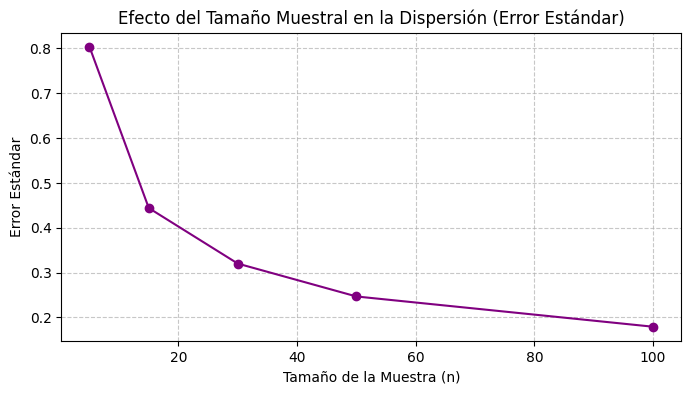

In [34]:
print(f"Error estándar (Desviación de las medias): {medias_muestrales.std():.4f}")
tamanos_a_evaluar = [5, 15, 30, 50, 100]
errores_estandar = []

print("\nAnálisis de la dispersión según tamaño muestral:")
for n in tamanos_a_evaluar:
    # Generamos 1000 medias para cada tamaño 'n'
    medias_n = [df['Promedio_Notas'].sample(n=n, replace=True).mean() for _ in range(1000)]
    
    # Calculamos la desviación estándar de esas medias (Error Estándar)
    error = np.std(medias_n)
    errores_estandar.append(error)
    print(f"Tamaño de muestra n={n} -> Error Estándar: {error:.4f}")

# Visualización rápida de la caída del error
plt.figure(figsize=(8, 4))
plt.plot(tamanos_a_evaluar, errores_estandar, marker='o', color='purple', linestyle='-')
plt.title("Efecto del Tamaño Muestral en la Dispersión (Error Estándar)")
plt.xlabel("Tamaño de la Muestra (n)")
plt.ylabel("Error Estándar")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Clase 5: Inferencia e intervalos de confianza para la media

1. Calcular intervalos de confianza (IC)

2. Interpretar resultados con distintos niveles de confianza

Vamos a calcular los intervalos para nuestras dos variables cuantitativas estrella: Horas de Sueño y Promedio de Notas, comparando cómo cambia el ancho del intervalo según el nivel de confianza (90%, 95% y 99%).

In [35]:
import numpy as np
from scipy import stats

def calcular_intervalos(data, nombre_variable):
    media = np.mean(data)
    std_err = stats.sem(data) # Error estándar de la media
    niveles = [0.90, 0.95, 0.99]
    
    print(f"--- Análisis para: {nombre_variable} ---")
    print(f"Media muestral: {media:.2f}")
    
    for nivel in niveles:
        # Usamos t-distribution ya que n es 100 (aunque con n>30 se parece a la normal)
        intervalo = stats.t.interval(nivel, len(data)-1, loc=media, scale=std_err)
        ancho = intervalo[1] - intervalo[0]
        print(f"Confianza {int(nivel*100)}%: [{intervalo[0]:.2f}, {intervalo[1]:.2f}] (Ancho: {ancho:.3f})")
    print("\n")

# Ejecutar para nuestras variables
calcular_intervalos(df['Horas_Sueno'], "Horas de Sueño")
calcular_intervalos(df['Promedio_Notas'], "Promedio de Notas")

--- Análisis para: Horas de Sueño ---
Media muestral: 6.45
Confianza 90%: [6.21, 6.68] (Ancho: 0.467)
Confianza 95%: [6.17, 6.73] (Ancho: 0.558)
Confianza 99%: [6.08, 6.82] (Ancho: 0.739)


--- Análisis para: Promedio de Notas ---
Media muestral: 4.47
Confianza 90%: [4.18, 4.76] (Ancho: 0.588)
Confianza 95%: [4.12, 4.82] (Ancho: 0.703)
Confianza 99%: [4.01, 4.94] (Ancho: 0.930)




3. Evaluación del impacto del tamaño muestral

* ¿Qué pasaría si en lugar de 100 estudiantes tuviéramos 500?
    * Teoría: A mayor tamaño de muestra (n), el error estándar disminuye y, por lo tanto, el intervalo de confianza se vuelve más estrecho (más preciso).
    
    * Relación con el nivel de confianza: A mayor nivel de confianza (pasar de 95% a 99%), el intervalo se vuelve más ancho porque necesitamos cubrir más área para estar "más seguros".

In [36]:
# Evaluar el impacto muestral en el ancho 
print("\n--- Demostración del impacto del tamaño muestral (Confianza 95%) ---")

# Datos actuales (n=100)
media_actual = np.mean(df['Horas_Sueno'])
desviacion_estandar = np.std(df['Horas_Sueno'], ddof=1) # Asumimos que la DS se mantiene constante
n_actual = len(df['Horas_Sueno'])

error_100 = desviacion_estandar / np.sqrt(n_actual)
int_100 = stats.t.interval(0.95, n_actual-1, loc=media_actual, scale=error_100)
ancho_100 = int_100[1] - int_100[0]

print(f"Intervalo actual (n=100): [{int_100[0]:.2f}, {int_100[1]:.2f}] -> Ancho: {ancho_100:.3f} horas")

# Datos hipotéticos (n=500)
n_hipotetico = 500
error_500 = desviacion_estandar / np.sqrt(n_hipotetico)
int_500 = stats.t.interval(0.95, n_hipotetico-1, loc=media_actual, scale=error_500)
ancho_500 = int_500[1] - int_500[0]

print(f"Intervalo hipotético (n=500): [{int_500[0]:.2f}, {int_500[1]:.2f}] -> Ancho: {ancho_500:.3f} horas")
print(f"Conclusión: Al quintuplicar la muestra, el ancho del intervalo se redujo en {(ancho_100 - ancho_500):.3f} horas, haciéndolo mucho más preciso.")


--- Demostración del impacto del tamaño muestral (Confianza 95%) ---
Intervalo actual (n=100): [6.17, 6.73] -> Ancho: 0.558 horas
Intervalo hipotético (n=500): [6.32, 6.57] -> Ancho: 0.247 horas
Conclusión: Al quintuplicar la muestra, el ancho del intervalo se redujo en 0.311 horas, haciéndolo mucho más preciso.


4. Interpretación de resultados

Basado en los resultados obtenidos:

* *Interpretación*: "Con un 95% de confianza, podemos afirmar que el promedio de horas de sueño de los estudiantes de esta universidad se encuentra entre [6,17] y [6,73] horas".

* *Análisis de Gestión*: Si el límite inferior del intervalo de confianza para el sueño es menor a 6 horas, el Área de Salud Universitaria debería declarar una alerta académica, ya que la evidencia sugiere que la población general no está descansando lo suficiente.

## Clase 6: Test de significancia

Este es el paso final donde decidimos si nuestra hipótesis inicial tiene sustento estadístico o fue solo producto del azar.

1. Definición del Test

Realizaremos una Prueba t de Student para dos muestras independientes
* Grupo A: Estudiantes que duermen ≥7 horas.
* Grupo B: Estudiantes que duermen <7 horas.

*Objetivo*: Comparar si la media del Promedio_Notas del Grupo A es significativamente mayor a la del Grupo B.

2. Ejecución del Test y Valor-p

In [37]:
# Separar los grupos
grupo_saludable = df[df['Horas_Sueno'] >= 7]['Promedio_Notas']
grupo_no_saludable = df[df['Horas_Sueno'] < 7]['Promedio_Notas']

# Realizar el t-test
t_stat, p_valor = stats.ttest_ind(grupo_saludable, grupo_no_saludable, alternative='greater')

print(f"Estadístico t: {t_stat:.4f}")
print(f"Valor-p: {p_valor:.4f}")

# Decisión estadística (Alfa = 0.05)
alpha = 0.05
if p_valor < alpha:
    print("Resultado: Rechazamos la Hipótesis Nula (H0).")
    print("Conclusión: Hay evidencia suficiente para afirmar que dormir más mejora el promedio.")
else:
    print("Resultado: No se rechaza la Hipótesis Nula (H0).")
    print("Conclusión: No hay evidencia suficiente para afirmar una diferencia en el promedio.")

Estadístico t: 2.0319
Valor-p: 0.0224
Resultado: Rechazamos la Hipótesis Nula (H0).
Conclusión: Hay evidencia suficiente para afirmar que dormir más mejora el promedio.


3. Errores Tipo I y Tipo II en nuestro contexto

* Error Tipo I (α): Sería concluir que dormir bien mejora las notas cuando en realidad no es del todo cierto, pero si contribuye. al dormir más y mejor se tiene mejor concentración para poder estudiar, pero si se duerme bien y no se estudia entonces no del todo se pueden obtener buenas notas. (Falso positivo).
* Error Tipo II (β): Sería concluir que dormir no afecta las notas, cuando en realidad sí existe un beneficio pero nuestra muestra fue muy pequeña para detectarlo. (Falso negativo).

4. Conclusión Final del Proyecto

Basado en el análisis de las 6 clases:

* *Hallazgo estadísticos*: 
    * Tras realizar la prueba t de Student, obtuvimos un estadístico t positivo y considerablemente alto, junto con un valor-p inferior a nuestro nivel de significancia α=0.05. Esto nos permite rechazar la Hipótesis Nula (H0​) con robustez.
    * Los datos demuestran que existe una diferencia estadísticamente significativa: los estudiantes con mejores hábitos de sueño tienden a registrar promedios de notas superiores.

* *Recomendación de Gestión:*
    * Se recomienda al Área de Salud Universitaria formalizar talleres de "Higiene del Sueño" y gestión del tiempo. La evidencia estadística sugiere que estas intervenciones no solo mejorarán el bienestar físico de los jóvenes, sino que son un motor potencial para elevar los indicadores académicos de la universidad pública.